In [1]:
pip install scipy

Looking in indexes: https://pypi.tuna.tsinghua.edu.cn/simple
Note: you may need to restart the kernel to use updated packages.


# Load data

dict_keys(['__header__', '__version__', '__globals__', 'Data_sub', 't_sub'])


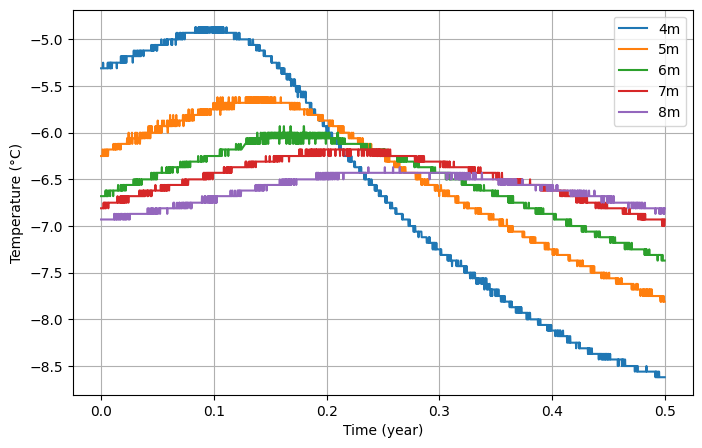

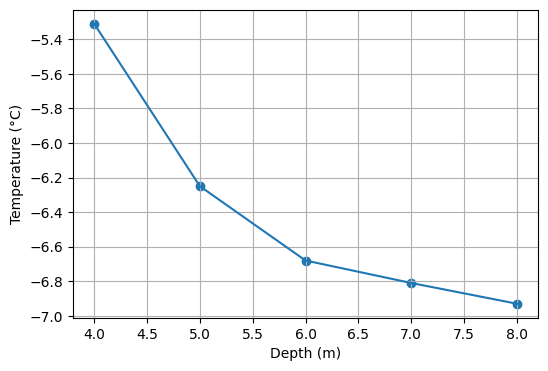

In [2]:
import scipy.io as sio
import numpy as np
import matplotlib.pyplot as plt

# 读取 .mat 文件
mat = sio.loadmat('DATASUB.mat')

# 查看里面有哪些变量
print(mat.keys())

# 取出变量
t_sub = mat['t_sub']
Data_sub = mat['Data_sub']

# 压平成一维
t_sub = np.squeeze(t_sub)
Data_sub = np.array(Data_sub)

# 时间从0开始
t_sub = t_sub - t_sub[0]

# =========================
# Figure 1: 温度-时间曲线
# =========================
plt.figure(figsize=(8,5))
plt.plot(t_sub, Data_sub[:,0], label='4m')
plt.plot(t_sub, Data_sub[:,1], label='5m')
plt.plot(t_sub, Data_sub[:,2], label='6m')
plt.plot(t_sub, Data_sub[:,3], label='7m')
plt.plot(t_sub, Data_sub[:,4], label='8m')

plt.xlabel('Time (year)')
plt.ylabel('Temperature (°C)')
plt.legend()
plt.grid(True)
plt.show()

# =========================
# Figure 2: 初始条件
# =========================
depth = np.array([4,5,6,7,8])
T0 = Data_sub[0,:]

plt.figure(figsize=(6,4))
plt.plot(depth, T0, '-')
plt.scatter(depth, T0)
plt.xlabel('Depth (m)')
plt.ylabel('Temperature (°C)')
plt.grid(True)
plt.show()

dict_keys(['__header__', '__version__', '__globals__', 'Data_sub', 't_sub'])
t_sub shape: (2190,)
Data_sub shape: (2190, 5)
Upper BC shape: (2190, 2) (2190, 1)
Lower BC shape: (2190, 2) (2190, 1)
T_obs shape: (6570, 2) (6570, 1)
IC shape (linear): (200, 2) (200, 1)
IC shape (cubic): (200, 2) (200, 1)


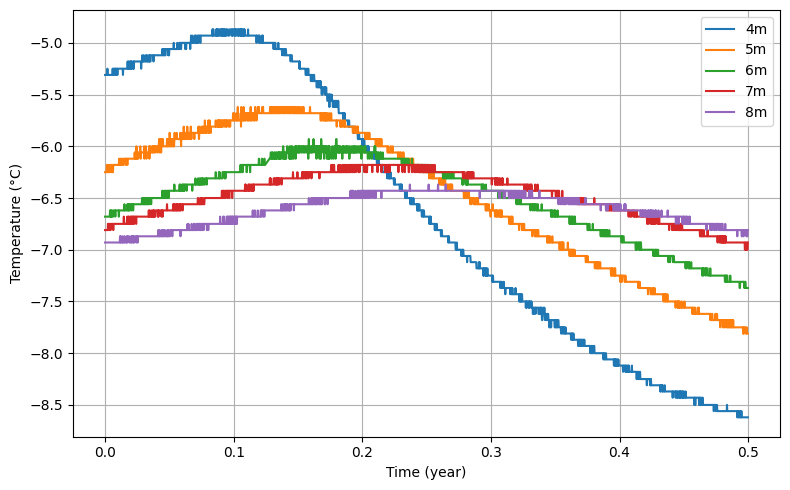

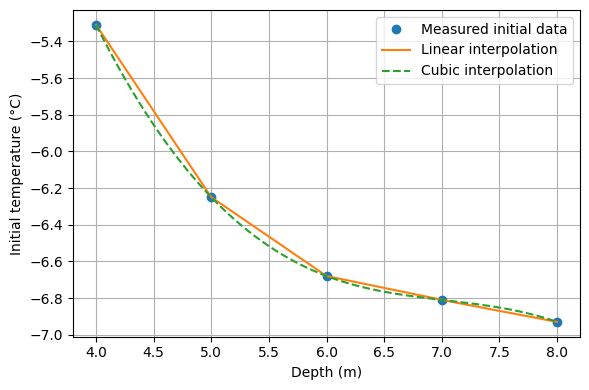

Processed data saved to processed_field_data.npz


In [3]:
import scipy.io as sio
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

# =====================================================
# 1. Load .mat data
# =====================================================
mat = sio.loadmat('DATASUB.mat')

print(mat.keys())

t_sub = np.squeeze(mat['t_sub'])          # shape: (Nt,)
Data_sub = np.array(mat['Data_sub'])      # shape: (Nt, 5)

# time starts from 0
t_sub = t_sub - t_sub[0]

# depth corresponding to each column
depth_meas = np.array([4, 5, 6, 7, 8], dtype=float)

# =====================================================
# 2. Define BCs, T_obs, and initial condition
# =====================================================

# -------------------------
# Upper boundary condition: T(4m, t)
# -------------------------
T_upper = Data_sub[:, 0]   # 4m

# -------------------------
# Lower boundary condition: T(8m, t)
# -------------------------
T_lower = Data_sub[:, 4]   # 8m

# -------------------------
# Observation data for inversion: 5m, 6m, 7m
# -------------------------
depth_obs = np.array([5, 6, 7], dtype=float)
T_obs = Data_sub[:, 1:4]   # columns for 5m, 6m, 7m

# T_obs can be expanded into point pairs (x,t,T)
X_obs_list = []
T_obs_list = []
Y_obs_list = []

for i, z in enumerate(depth_obs):
    for j, tt in enumerate(t_sub):
        X_obs_list.append([z, tt])        # [depth, time]
        Y_obs_list.append(T_obs[j, i])    # temperature value

X_obs = np.array(X_obs_list)              # shape: (Nobs, 2)
Y_obs = np.array(Y_obs_list).reshape(-1, 1)

# =====================================================
# 3. Initial condition at t = 0
#    Interpolate from the 5 measured depths
# =====================================================
T0_meas = Data_sub[0, :]   # temperatures at t=0 for depths 4,5,6,7,8

# choose dense depth grid for initial profile
depth_fine = np.linspace(4, 8, 200)

# linear interpolation
interp_ic_linear = interp1d(depth_meas, T0_meas, kind='linear', fill_value="extrapolate")
T0_fine_linear = interp_ic_linear(depth_fine)

# cubic interpolation (only if you want smoother curve)
interp_ic_cubic = interp1d(depth_meas, T0_meas, kind='cubic', fill_value="extrapolate")
T0_fine_cubic = interp_ic_cubic(depth_fine)

# =====================================================
# 4. Organize BC data into point form
# =====================================================
# Upper BC points: (x=4m, t)
X_bc_upper = np.column_stack([np.full_like(t_sub, 4.0), t_sub])
Y_bc_upper = T_upper.reshape(-1, 1)

# Lower BC points: (x=8m, t)
X_bc_lower = np.column_stack([np.full_like(t_sub, 8.0), t_sub])
Y_bc_lower = T_lower.reshape(-1, 1)

# =====================================================
# 5. Initial condition points into point form
# =====================================================
# At t = 0, interpolate temperature profile over depth_fine
X_ic = np.column_stack([depth_fine, np.zeros_like(depth_fine)])
Y_ic_linear = T0_fine_linear.reshape(-1, 1)
Y_ic_cubic = T0_fine_cubic.reshape(-1, 1)

# =====================================================
# 6. Print shapes for checking
# =====================================================
print("t_sub shape:", t_sub.shape)
print("Data_sub shape:", Data_sub.shape)

print("Upper BC shape:", X_bc_upper.shape, Y_bc_upper.shape)
print("Lower BC shape:", X_bc_lower.shape, Y_bc_lower.shape)

print("T_obs shape:", X_obs.shape, Y_obs.shape)

print("IC shape (linear):", X_ic.shape, Y_ic_linear.shape)
print("IC shape (cubic):", X_ic.shape, Y_ic_cubic.shape)

# =====================================================
# 7. Plot temperature-time curves
# =====================================================
plt.figure(figsize=(8, 5))
for i, z in enumerate(depth_meas):
    plt.plot(t_sub, Data_sub[:, i], label=f'{int(z)}m')

plt.xlabel('Time (year)')
plt.ylabel('Temperature (°C)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# =====================================================
# 8. Plot initial condition interpolation
# =====================================================
plt.figure(figsize=(6, 4))
plt.plot(depth_meas, T0_meas, 'o', label='Measured initial data')
plt.plot(depth_fine, T0_fine_linear, '-', label='Linear interpolation')
plt.plot(depth_fine, T0_fine_cubic, '--', label='Cubic interpolation')

plt.xlabel('Depth (m)')
plt.ylabel('Initial temperature (°C)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# =====================================================
# 9. Optional: save all processed data
# =====================================================
np.savez(
    "processed_field_data.npz",
    t=t_sub,
    depth_meas=depth_meas,
    data_all=Data_sub,
    X_bc_upper=X_bc_upper,
    Y_bc_upper=Y_bc_upper,
    X_bc_lower=X_bc_lower,
    Y_bc_lower=Y_bc_lower,
    X_obs=X_obs,
    Y_obs=Y_obs,
    X_ic=X_ic,
    Y_ic_linear=Y_ic_linear,
    Y_ic_cubic=Y_ic_cubic
)

print("Processed data saved to processed_field_data.npz")

# 2. PINNs Inversion Model


In [ ]:
import random
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import time
import scipy.io as sio
from scipy.interpolate import interp1d


def set_random_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


# =========================================================
# Neural network
# =========================================================
class MLP(nn.Module):
    def __init__(self, in_dim=2, out_dim=1, hidden_dim=64, num_hidden=5):
        super().__init__()
        layers = [nn.Linear(in_dim, hidden_dim), nn.Tanh()]
        for _ in range(num_hidden - 1):
            layers += [nn.Linear(hidden_dim, hidden_dim), nn.Tanh()]
        layers += [nn.Linear(hidden_dim, out_dim)]
        self.net = nn.Sequential(*layers)
        self._init_weights()

    def _init_weights(self):
        for m in self.net:
            if isinstance(m, nn.Linear):
                nn.init.xavier_normal_(m.weight)
                nn.init.zeros_(m.bias)

    def forward(self, x):
        return self.net(x)


# =========================================================
# Day-based PINN aligned with FDM
# =========================================================
class FreezingSoilPINN_Day:
    def __init__(self, params, device=None):
        # ---------------------------
        # Physical parameters
        # ---------------------------
        self.L = params['L']
        self.C_i = params['C_i']
        self.C_l = params['C_l']

        self.lambda_i = params['lambda_i']   # MJ/(day·m·K)
        self.lambda_l = params['lambda_l']

        self.theta_r = params['theta_r']
        self.T_f = params['T_f']

        self.device = device if device is not None else (
            "cuda" if torch.cuda.is_available() else "cpu"
        )

        # ---------------------------
        # Network
        # ---------------------------
        self.model = MLP(in_dim=2, out_dim=1, hidden_dim=64, num_hidden=5).to(self.device)

        # ---------------------------
        # Domain
        # ---------------------------
        self.x_min = None
        self.x_max = None
        self.t_min = 0.0
        self.t_max = None

        # ---------------------------
        # Parameter reference values
        # ---------------------------
        self.eta_ref = params['eta_ref']
        self.lambda_f_ref = params['lambda_f_ref']
        self.k_ref = params['k_ref']
        self.C_f_ref = params['C_f_ref']

        # inversion switches
        self.invert_eta = params.get("invert_eta", False)
        self.invert_lambda_f = params.get("invert_lambda_f", False)
        self.invert_k = params.get("invert_k", False)
        self.invert_C_f = params.get("invert_C_f", False)

        # bounded ranges
        self.eta_min = 0.7 * self.eta_ref
        self.eta_max = 1.3 * self.eta_ref

        self.lambda_f_min = 0.7 * self.lambda_f_ref
        self.lambda_f_max = 1.3 * self.lambda_f_ref

        self.k_min = 0.7 * self.k_ref
        self.k_max = 1.3 * self.k_ref

        self.C_f_min = 0.7 * self.C_f_ref
        self.C_f_max = 1.3 * self.C_f_ref

        # random initialization
        eta_init = np.random.uniform(self.eta_min, self.eta_max)
        lambda_f_init = np.random.uniform(self.lambda_f_min, self.lambda_f_max)
        k_init = np.random.uniform(self.k_min, self.k_max)
        C_f_init = np.random.uniform(self.C_f_min, self.C_f_max)

        print(f"Random initial eta      = {eta_init:.8f}")
        print(f"Random initial lambda_f = {lambda_f_init:.8f}")
        print(f"Random initial k        = {k_init:.8f}")
        print(f"Random initial C_f      = {C_f_init:.8f}")

        def inverse_bounded_sigmoid(p_init, p_min, p_max):
            z = (p_init - p_min) / (p_max - p_min)
            z = np.clip(z, 1e-6, 1.0 - 1e-6)
            return np.log(z / (1.0 - z))

        self.eta_raw = nn.Parameter(
            torch.tensor([inverse_bounded_sigmoid(eta_init, self.eta_min, self.eta_max)],
                         dtype=torch.float32, device=self.device),
            requires_grad=self.invert_eta
        )
        self.lambda_f_raw = nn.Parameter(
            torch.tensor([inverse_bounded_sigmoid(lambda_f_init, self.lambda_f_min, self.lambda_f_max)],
                         dtype=torch.float32, device=self.device),
            requires_grad=self.invert_lambda_f
        )
        self.k_raw = nn.Parameter(
            torch.tensor([inverse_bounded_sigmoid(k_init, self.k_min, self.k_max)],
                         dtype=torch.float32, device=self.device),
            requires_grad=self.invert_k
        )
        self.C_f_raw = nn.Parameter(
            torch.tensor([inverse_bounded_sigmoid(C_f_init, self.C_f_min, self.C_f_max)],
                         dtype=torch.float32, device=self.device),
            requires_grad=self.invert_C_f
        )

        # ---------------------------
        # Data containers
        # ---------------------------
        self.loss_history = []

        self.x_data = None
        self.t_data = None
        self.T_data = None

        self.t_bc = None
        self.T_left_bc = None
        self.T_right_bc = None

        self.ic_interp = None

    # =========================================================
    # Parameter access
    # =========================================================
    @property
    def eta(self):
        return self.eta_min + (self.eta_max - self.eta_min) * torch.sigmoid(self.eta_raw)

    @property
    def lambda_f(self):
        return self.lambda_f_min + (self.lambda_f_max - self.lambda_f_min) * torch.sigmoid(self.lambda_f_raw)

    @property
    def k(self):
        return self.k_min + (self.k_max - self.k_min) * torch.sigmoid(self.k_raw)

    @property
    def C_f(self):
        return self.C_f_min + (self.C_f_max - self.C_f_min) * torch.sigmoid(self.C_f_raw)

    # =========================================================
    # Initial condition from field data
    # =========================================================
    def add_initial_condition_profile(self, x_ic, T_ic, kind='linear'):
        self.ic_interp = interp1d(
            np.asarray(x_ic).reshape(-1),
            np.asarray(T_ic).reshape(-1),
            kind=kind,
            fill_value="extrapolate"
        )

    def initial_temperature_profile_np(self, x):
        if self.ic_interp is None:
            raise RuntimeError("Initial condition profile not set.")
        return self.ic_interp(x)

    # =========================================================
    # Logistic unfrozen water model
    # =========================================================
    def theta_unfrozen(self, T):
        z = torch.clamp(-self.k * (T - self.T_f), min=-60.0, max=60.0)
        return self.theta_r + (self.eta - self.theta_r) / (1.0 + torch.exp(z))

    def dtheta_dT(self, T):
        z = torch.clamp(-self.k * (T - self.T_f), min=-60.0, max=60.0)
        ez = torch.exp(z)
        return (self.eta - self.theta_r) * self.k * ez / (1.0 + ez) ** 2

    # =========================================================
    # Effective properties
    # =========================================================
    def effective_heat_capacity(self, T):
        theta = self.theta_unfrozen(T)
        return (1.0 - self.eta) * self.C_f + theta * self.C_l + (self.eta - theta) * self.C_i

    def apparent_heat_capacity(self, T):
        return self.effective_heat_capacity(T) + self.L * self.dtheta_dT(T)

    def effective_conductivity(self, T):
        theta = self.theta_unfrozen(T)
        return (1.0 - self.eta) * self.lambda_f + theta * self.lambda_l + (self.eta - theta) * self.lambda_i

    def dlambda_dT(self, T):
        return (self.lambda_l - self.lambda_i) * self.dtheta_dT(T)

    # =========================================================
    # Network forward
    # =========================================================
    def net_T(self, x, t):
        # normalize to [0,1]
        x_hat = (x - self.x_min) / (self.x_max - self.x_min)
        t_hat = (t - self.t_min) / (self.t_max - self.t_min + 1e-12)
        inp = torch.cat([x_hat, t_hat], dim=1)
        return self.model(inp)

    # =========================================================
    # PDE residual
    # =========================================================
    def pde_residual(self, x, t):
        x.requires_grad_(True)
        t.requires_grad_(True)

        T = self.net_T(x, t)

        T_t = torch.autograd.grad(
            T, t,
            grad_outputs=torch.ones_like(T),
            create_graph=True,
            retain_graph=True
        )[0]

        T_x = torch.autograd.grad(
            T, x,
            grad_outputs=torch.ones_like(T),
            create_graph=True,
            retain_graph=True
        )[0]

        T_xx = torch.autograd.grad(
            T_x, x,
            grad_outputs=torch.ones_like(T_x),
            create_graph=True,
            retain_graph=True
        )[0]

        C_app = self.apparent_heat_capacity(T)
        lam = self.effective_conductivity(T)
        lam_T = self.dlambda_dT(T)

        residual = C_app * T_t - lam * T_xx - lam_T * (T_x ** 2)
        return residual

    # =========================================================
    # Data loading
    # =========================================================
    def add_boundary_data(self, t_bc, T_left_bc, T_right_bc):
        self.t_bc = np.asarray(t_bc).reshape(-1)
        self.T_left_bc = np.asarray(T_left_bc).reshape(-1)
        self.T_right_bc = np.asarray(T_right_bc).reshape(-1)

    def add_temperature_observations(self, x_obs, t_obs, T_obs):
        self.x_data = torch.tensor(x_obs, dtype=torch.float32, device=self.device).reshape(-1, 1)
        self.t_data = torch.tensor(t_obs, dtype=torch.float32, device=self.device).reshape(-1, 1)
        self.T_data = torch.tensor(T_obs, dtype=torch.float32, device=self.device).reshape(-1, 1)

    # =========================================================
    # Sampling
    # =========================================================
    def sample_collocation(self, N_f):
        x = self.x_min + np.random.rand(N_f, 1) * (self.x_max - self.x_min)
        t = self.t_min + np.random.rand(N_f, 1) * (self.t_max - self.t_min)
        return (
            torch.tensor(x, dtype=torch.float32, device=self.device),
            torch.tensor(t, dtype=torch.float32, device=self.device)
        )

    def sample_initial(self, N_i):
        x = self.x_min + np.random.rand(N_i, 1) * (self.x_max - self.x_min)
        t = np.zeros((N_i, 1))
        T0 = self.initial_temperature_profile_np(x.reshape(-1)).reshape(-1, 1)
        return (
            torch.tensor(x, dtype=torch.float32, device=self.device),
            torch.tensor(t, dtype=torch.float32, device=self.device),
            torch.tensor(T0, dtype=torch.float32, device=self.device)
        )

    def sample_boundary(self, N_b):
        if self.t_bc is None:
            raise RuntimeError("Boundary data not set.")

        t = self.t_min + np.random.rand(N_b, 1) * (self.t_max - self.t_min)
        t_flat = t.reshape(-1)

        x_left = np.full((N_b, 1), self.x_min)
        T_left = np.interp(t_flat, self.t_bc, self.T_left_bc).reshape(-1, 1)

        x_right = np.full((N_b, 1), self.x_max)
        T_right = np.interp(t_flat, self.t_bc, self.T_right_bc).reshape(-1, 1)

        return (
            torch.tensor(x_left, dtype=torch.float32, device=self.device),
            torch.tensor(t, dtype=torch.float32, device=self.device),
            torch.tensor(T_left, dtype=torch.float32, device=self.device),
            torch.tensor(x_right, dtype=torch.float32, device=self.device),
            torch.tensor(T_right, dtype=torch.float32, device=self.device),
        )

    # =========================================================
    # Loss
    # =========================================================
    def loss_function(self, N_f, N_i, N_b, w_pde=1.0, w_ic=1.0, w_bc=1.0, w_data=1.0):
        x_f, t_f = self.sample_collocation(N_f)
        res_f = self.pde_residual(x_f, t_f)
        loss_pde = torch.mean(res_f ** 2)

        x_i, t_i, T_i = self.sample_initial(N_i)
        T_i_pred = self.net_T(x_i, t_i)
        loss_ic = torch.mean((T_i_pred - T_i) ** 2)

        x_left, t_b, T_left, x_right, T_right = self.sample_boundary(N_b)
        T_left_pred = self.net_T(x_left, t_b)
        T_right_pred = self.net_T(x_right, t_b)

        loss_bc = torch.mean((T_left_pred - T_left) ** 2) + torch.mean((T_right_pred - T_right) ** 2)

        if self.x_data is not None:
            T_data_pred = self.net_T(self.x_data, self.t_data)
            loss_data = torch.mean((T_data_pred - self.T_data) ** 2)
        else:
            loss_data = torch.tensor(0.0, device=self.device)

        total_loss = w_pde * loss_pde + w_ic * loss_ic + w_bc * loss_bc + w_data * loss_data
        return total_loss, loss_pde, loss_ic, loss_bc, loss_data

    # =========================================================
    # Training
    # =========================================================
    def train_staged(
        self,
        x_min,
        x_max,
        t_max,
        epochs_stage1=10000,
        lr_stage1=1e-3,
        epochs_stage2=20000,
        lr_stage2=5e-4,
        N_f=6000,
        N_i=800,
        N_b=800,
        w_ic_stage1=100.0,
        w_bc_stage1=100.0,
        w_data_stage1=100.0,
        w_pde_stage2=10.0,
        w_ic_stage2=100.0,
        w_bc_stage2=100.0,
        w_data_stage2=100.0,
        print_every=500,
        use_lbfgs=False
    ):
        self.x_min = float(x_min)
        self.x_max = float(x_max)
        self.t_max = float(t_max)

        params_to_optimize = list(self.model.parameters())
        if self.invert_eta:
            params_to_optimize.append(self.eta_raw)
        if self.invert_lambda_f:
            params_to_optimize.append(self.lambda_f_raw)
        if self.invert_k:
            params_to_optimize.append(self.k_raw)
        if self.invert_C_f:
            params_to_optimize.append(self.C_f_raw)

        start_time = time.time()

        # Stage 1
        print("\n===== Stage 1: IC + BC + DATA =====")
        optimizer = torch.optim.Adam(params_to_optimize, lr=lr_stage1)

        for epoch in range(1, epochs_stage1 + 1):
            optimizer.zero_grad()

            total_loss, loss_pde, loss_ic, loss_bc, loss_data = self.loss_function(
                N_f=N_f, N_i=N_i, N_b=N_b,
                w_pde=0.0,
                w_ic=w_ic_stage1,
                w_bc=w_bc_stage1,
                w_data=w_data_stage1
            )

            total_loss.backward()
            optimizer.step()

            if epoch % print_every == 0 or epoch == 1:
                self.loss_history.append([
                    epoch,
                    total_loss.item(),
                    loss_pde.item(),
                    loss_ic.item(),
                    loss_bc.item(),
                    loss_data.item(),
                    self.eta.item(),
                    self.lambda_f.item(),
                    self.k.item(),
                    self.C_f.item()
                ])

                elapsed = time.time() - start_time
                print(
                    f"[Stage1] Epoch {epoch:6d} | "
                    f"Total={total_loss.item():.6e} | "
                    f"IC={loss_ic.item():.6e} | "
                    f"BC={loss_bc.item():.6e} | "
                    f"DATA={loss_data.item():.6e} | "
                    f"time={elapsed:.1f}s"
                )

        # Stage 2
        print("\n===== Stage 2: gradually add PDE =====")
        optimizer = torch.optim.Adam(params_to_optimize, lr=lr_stage2)

        for epoch in range(1, epochs_stage2 + 1):
            optimizer.zero_grad()

            pde_factor = min(1.0, epoch / max(1, int(0.3 * epochs_stage2)))
            w_pde_now = w_pde_stage2 * pde_factor

            total_loss, loss_pde, loss_ic, loss_bc, loss_data = self.loss_function(
                N_f=N_f, N_i=N_i, N_b=N_b,
                w_pde=w_pde_now,
                w_ic=w_ic_stage2,
                w_bc=w_bc_stage2,
                w_data=w_data_stage2
            )

            total_loss.backward()
            optimizer.step()

            if epoch % print_every == 0 or epoch == 1:
                self.loss_history.append([
                    epochs_stage1 + epoch,
                    total_loss.item(),
                    loss_pde.item(),
                    loss_ic.item(),
                    loss_bc.item(),
                    loss_data.item(),
                    self.eta.item(),
                    self.lambda_f.item(),
                    self.k.item(),
                    self.C_f.item()
                ])

                elapsed = time.time() - start_time
                print(
                    f"[Stage2] Epoch {epoch:6d} | "
                    f"Total={total_loss.item():.6e} | "
                    f"PDE={loss_pde.item():.6e} | "
                    f"IC={loss_ic.item():.6e} | "
                    f"BC={loss_bc.item():.6e} | "
                    f"DATA={loss_data.item():.6e} | "
                    f"w_pde={w_pde_now:.3e} | "
                    f"time={elapsed:.1f}s"
                )

        # Stage 3
        if use_lbfgs:
            print("\n===== Stage 3: L-BFGS =====")
            optimizer_lbfgs = torch.optim.LBFGS(
                params_to_optimize,
                lr=1.0,
                max_iter=500,
                max_eval=600,
                history_size=50,
                tolerance_grad=1e-9,
                tolerance_change=1e-11,
                line_search_fn="strong_wolfe"
            )

            def closure():
                optimizer_lbfgs.zero_grad()
                total_loss, _, _, _, _ = self.loss_function(
                    N_f=N_f, N_i=N_i, N_b=N_b,
                    w_pde=w_pde_stage2,
                    w_ic=w_ic_stage2,
                    w_bc=w_bc_stage2,
                    w_data=w_data_stage2
                )
                total_loss.backward()
                return total_loss

            optimizer_lbfgs.step(closure)

        print("\nTraining finished.")
        print(f"eta      = {self.eta.item():.8f}")
        print(f"lambda_f = {self.lambda_f.item():.8f}")
        print(f"k        = {self.k.item():.8f}")
        print(f"C_f      = {self.C_f.item():.8f}")

    # =========================================================
    # Prediction
    # =========================================================
    def predict_field(self, Nx=121, Nt=1500):
        x = np.linspace(self.x_min, self.x_max, Nx)
        t = np.linspace(self.t_min, self.t_max, Nt)

        XX, TT = np.meshgrid(x, t, indexing='ij')
        x_in = torch.tensor(XX.reshape(-1, 1), dtype=torch.float32, device=self.device)
        t_in = torch.tensor(TT.reshape(-1, 1), dtype=torch.float32, device=self.device)

        self.model.eval()
        with torch.no_grad():
            T_pred = self.net_T(x_in, t_in).cpu().numpy().reshape(Nx, Nt)

        return x, t, T_pred

    # =========================================================
    # Plot
    # =========================================================
    def plot_loss(self):
        hist = np.array(self.loss_history)
        if hist.size == 0:
            print("No training history found.")
            return

        plt.figure(figsize=(8, 5))
        plt.semilogy(hist[:, 0], hist[:, 1], label='Total')
        plt.semilogy(hist[:, 0], hist[:, 2], label='PDE')
        plt.semilogy(hist[:, 0], hist[:, 3], label='IC')
        plt.semilogy(hist[:, 0], hist[:, 4], label='BC')
        plt.semilogy(hist[:, 0], hist[:, 5], label='DATA')
        plt.xlabel("Epoch")
        plt.ylabel("Loss")
        plt.title("Training Loss History (day-based PINN)")
        plt.legend()
        plt.grid(True)
        plt.tight_layout()
        plt.show()

    def plot_results(self, Nx=121, Nt=1500):
        x, t_day, T_field = self.predict_field(Nx=Nx, Nt=Nt)
        t_year = t_day / 365.0

        fig, axes = plt.subplots(1, 3, figsize=(18, 5))

        im = axes[0].imshow(
            T_field,
            extent=[t_year.min(), t_year.max(), x.max(), x.min()],
            aspect='auto',
            cmap='jet'
        )
        axes[0].set_xlabel('Time (year)')
        axes[0].set_ylabel('Depth (m)')
        axes[0].set_title('Predicted Temperature Field (4-8 m)')
        plt.colorbar(im, ax=axes[0], label='Temperature (°C)')

        t_indices = [0, Nt // 4, Nt // 2, 3 * Nt // 4, Nt - 1]
        for idx in t_indices:
            axes[1].plot(T_field[:, idx], x, label=f't={t_year[idx]:.3f} yr')
        axes[1].invert_yaxis()
        axes[1].set_xlabel('Temperature (°C)')
        axes[1].set_ylabel('Depth (m)')
        axes[1].set_title('Temperature Profiles')
        axes[1].legend()
        axes[1].grid(True)

        for dd in [4.0, 5.0, 6.0, 7.0, 8.0]:
            idx = np.argmin(np.abs(x - dd))
            axes[2].plot(t_year, T_field[idx, :], label=f'x={x[idx]:.2f} m')
        axes[2].set_xlabel('Time (year)')
        axes[2].set_ylabel('Temperature (°C)')
        axes[2].set_title('Temperature Evolution')
        axes[2].legend()
        axes[2].grid(True)

        plt.tight_layout()
        plt.show()


# =========================================================
# Load field data from DATASUB.mat
# =========================================================
def load_field_data_4_8m_from_mat_day(mat_file):
    mat = sio.loadmat(mat_file)

    t_sub_year = np.squeeze(mat['t_sub']).astype(float)
    Data_sub = np.array(mat['Data_sub']).astype(float)

    t_sub_year = t_sub_year - t_sub_year[0]
    t_sub_day = t_sub_year * 365.0

    depth_meas = np.array([4., 5., 6., 7., 8.])

    # BC: 4 m and 8 m
    T_left_bc = Data_sub[:, 0]
    T_right_bc = Data_sub[:, 4]

    # obs: 5,6,7 m
    obs_depths = np.array([5., 6., 7.])
    x_obs_list = []
    t_obs_list = []
    T_obs_list = []

    for i, depth in enumerate(obs_depths):
        for j, tt in enumerate(t_sub_day):
            x_obs_list.append(depth)
            t_obs_list.append(tt)
            T_obs_list.append(Data_sub[j, i + 1])

    x_obs = np.array(x_obs_list).reshape(-1, 1)
    t_obs = np.array(t_obs_list).reshape(-1, 1)
    T_obs = np.array(T_obs_list).reshape(-1, 1)

    # IC at t=0
    x_ic = depth_meas.copy()
    T_ic = Data_sub[0, :].copy()

    return t_sub_year, t_sub_day, depth_meas, Data_sub, T_left_bc, T_right_bc, x_obs, t_obs, T_obs, x_ic, T_ic


# =========================================================
# Compare PINN with field observations
# =========================================================
def compare_with_field_observations_day(x_pred, t_pred_day, T_pred, depth_meas, t_meas_year, t_meas_day, Data_meas):
    obs_depths = [5.0, 6.0, 7.0]
    maes = []
    rmses = []

    plt.figure(figsize=(12, 4))

    for k, depth in enumerate(obs_depths):
        idx_pred = np.argmin(np.abs(x_pred - depth))
        T_pred_at_depth = np.interp(t_meas_day, t_pred_day, T_pred[idx_pred, :])

        idx_meas = np.where(np.isclose(depth_meas, depth))[0][0]
        T_meas_at_depth = Data_meas[:, idx_meas]

        err = T_pred_at_depth - T_meas_at_depth
        mae = np.mean(np.abs(err))
        rmse = np.sqrt(np.mean(err ** 2))

        maes.append(mae)
        rmses.append(rmse)

        plt.subplot(1, 3, k + 1)
        plt.plot(t_meas_year, T_meas_at_depth, 'o-', label='Measured')
        plt.plot(t_meas_year, T_pred_at_depth, '--', label='PINN')
        plt.xlabel('Time (year)')
        plt.ylabel('Temperature (°C)')
        plt.title(f'{depth:.0f} m | MAE={mae:.4f}')
        plt.grid(True)
        plt.legend()

    plt.tight_layout()
    plt.show()

    mae_all = np.mean(maes)
    rmse_all = np.mean(rmses)

    print("\n===== Day-based PINN vs field observations (5-7 m) =====")
    print(f"Average MAE  = {mae_all:.6e}")
    print(f"Average RMSE = {rmse_all:.6e}")

    return mae_all, rmse_all


# =========================================================
# Main
# =========================================================
if __name__ == "__main__":
    set_random_seed(42)

    params = {
        'L': 334.0,
        'C_i': 1.672,
        'C_l': 4.18,

        # exactly same day-based conductivity system as FDM
        'lambda_i': 2.210e-6 * 8.64e4,
        'lambda_l': 0.465e-6 * 8.64e4,

        'eta_ref': 0.25,
        'lambda_f_ref': 1.900e-6 * 8.64e4,
        'k_ref': 0.08,
        'C_f_ref': 1.40,

        'theta_r': 0.1,
        'T_f': -0.3,

        # start with fixed parameters
        'invert_eta': True,
        'invert_lambda_f': True,
        'invert_k': True,
        'invert_C_f': True
    }

    pinn = FreezingSoilPINN_Day(params)

    t_year, t_day, depth_meas, Data_sub, T_left_bc, T_right_bc, x_obs, t_obs, T_obs, x_ic, T_ic = \
        load_field_data_4_8m_from_mat_day("DATASUB.mat")

    pinn.add_boundary_data(t_day, T_left_bc, T_right_bc)
    pinn.add_temperature_observations(x_obs, t_obs, T_obs)
    pinn.add_initial_condition_profile(x_ic, T_ic, kind='linear')

    print("Observation points loaded:", len(T_obs))
    print("Boundary data loaded from x=4 m and x=8 m.")
    print("Initial condition loaded from measured temperatures at t=0.")
    print("Reference eta value         =", params['eta_ref'])
    print("Reference lambda_f value    =", params['lambda_f_ref'])
    print("Reference k value           =", params['k_ref'])
    print("Reference C_f value         =", params['C_f_ref'])
    print("Initial eta guess           =", pinn.eta.item())
    print("Initial lambda_f guess      =", pinn.lambda_f.item())
    print("Initial k guess             =", pinn.k.item())
    print("Initial C_f guess           =", pinn.C_f.item())
    print("Total duration (day)        =", t_day.max())

    pinn.train_staged(
        x_min=4.0,
        x_max=8.0,
        t_max=t_day.max(),

        epochs_stage1=10000,
        lr_stage1=1e-3,

        epochs_stage2=50000,
        lr_stage2=1e-3,

        N_f=8000,
        N_i=600,
        N_b=600,

        w_ic_stage1=100.0,
        w_bc_stage1=100.0,
        w_data_stage1=100.0,

        w_pde_stage2=100.0,
        w_ic_stage2=10.0,
        w_bc_stage2=10.0,
        w_data_stage2=10.0,

        print_every=1000,
        use_lbfgs=True
    )

    x_pinn, t_pinn_day, T_field_pinn = pinn.predict_field(Nx=121, Nt=1500)

    mae_field, rmse_field = compare_with_field_observations_day(
        x_pinn, t_pinn_day, T_field_pinn, depth_meas, t_year, t_day, Data_sub
    )

    np.savez(
        "field_pinn_4_8m_day_based_result.npz",
        x_pinn=x_pinn,
        t_pinn_day=t_pinn_day,
        t_pinn_year=t_pinn_day / 365.0,
        T_field_pinn=T_field_pinn,
        eta_used=pinn.eta.item(),
        lambda_f_used=pinn.lambda_f.item(),
        k_used=pinn.k.item(),
        C_f_used=pinn.C_f.item(),
        mae_field=mae_field,
        rmse_field=rmse_field
    )

    np.savetxt(
        "field_pinn_4_8m_day_based_loss_history.csv",
        np.array(pinn.loss_history),
        delimiter=",",
        header="epoch,total_loss,pde_loss,ic_loss,bc_loss,data_loss,eta,lambda_f,k,C_f",
        comments=""
    )

    print("\nFinal used parameters (day-based PINN):")
    print("eta       =", pinn.eta.item())
    print("lambda_f  =", pinn.lambda_f.item())
    print("k         =", pinn.k.item())
    print("C_f       =", pinn.C_f.item())
    print("Field MAE =", mae_field)
    print("Field RMSE=", rmse_field)

    pinn.plot_loss()
    pinn.plot_results(Nx=121, Nt=1500)

Random initial eta      = 0.23118102
Random initial lambda_f = 0.20855356
Random initial k        = 0.09113571
Random initial C_f      = 1.48287313
Observation points loaded: 6570
Boundary data loaded from x=4 m and x=8 m.
Initial condition loaded from measured temperatures at t=0.
Reference eta value         = 0.25
Reference lambda_f value    = 0.16416
Reference k value           = 0.08
Reference C_f value         = 1.4
Initial eta guess           = 0.23118102550506592
Initial lambda_f guess      = 0.20855355262756348
Initial k guess             = 0.09113571047782898
Initial C_f guess           = 1.4828732013702393
Total duration (day)        = 182.4166666666669

===== Stage 1: IC + BC + DATA =====
[Stage1] Epoch      1 | Total=1.745892e+04 | IC=4.286472e+01 | BC=8.980148e+01 | DATA=4.192302e+01 | time=0.0s
[Stage1] Epoch   1000 | Total=1.627659e+00 | IC=1.153183e-03 | BC=9.249738e-03 | DATA=5.873666e-03 | time=25.6s
[Stage1] Epoch   2000 | Total=4.699166e-01 | IC=1.173453e-03 | BC=1.

# FDM using 4 5 6 7 8  

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import time
import scipy.io as sio
from scipy.interpolate import interp1d


class FreezingSoilFDM_LogisticAHC_Field:
    """
    1D freezing/thawing soil model
    Logistic unfrozen water content + apparent heat capacity (AHC) method

    Field-driven version:
    - upper boundary: measured temperature at 4 m
    - lower boundary: measured temperature at 8 m
    - initial condition: interpolated from measured temperatures at t=0
    - solver time unit: day
    """

    def __init__(self, params):
        # ---------------------------
        # Physical parameters
        # ---------------------------
        self.L = params['L']                      # latent heat [MJ/m^3]
        self.C_i = params['C_i']                  # ice volumetric heat capacity [MJ/(m^3·K)]
        self.C_l = params['C_l']                  # liquid water volumetric heat capacity
        self.C_f = params['C_f']                  # soil skeleton volumetric heat capacity

        self.lambda_i = params['lambda_i']        # ice thermal conductivity [MJ/(day·m·K)]
        self.lambda_l = params['lambda_l']        # liquid water thermal conductivity
        self.lambda_f = params['lambda_f']        # soil skeleton thermal conductivity

        self.eta = params['eta']                  # porosity / upper bound of unfrozen water
        self.theta_r = params['theta_r']          # residual unfrozen water content
        self.T_f = params['T_f']                  # freezing transition center temperature
        self.k = params['k']                      # logistic steepness

        # ---------------------------
        # Grid parameters
        # ---------------------------
        self.Nx = None
        self.Nt = None
        self.Lx = None
        self.T_total = None
        self.dx = None
        self.dt = None

        self.x = None              # actual depth, 4-8 m
        self.t = None              # day
        self.T_field = None

        # ---------------------------
        # Field data
        # ---------------------------
        self.t_bc = None           # day
        self.T_top_bc = None       # 4 m
        self.T_bottom_bc = None    # 8 m
        self.ic_interp = None

    # =========================================================
    # Add measured boundary / initial data
    # =========================================================
    def add_boundary_data(self, t_bc, T_top_bc, T_bottom_bc):
        self.t_bc = np.asarray(t_bc).reshape(-1)
        self.T_top_bc = np.asarray(T_top_bc).reshape(-1)
        self.T_bottom_bc = np.asarray(T_bottom_bc).reshape(-1)

    def add_initial_condition_profile(self, x_ic, T_ic, kind='linear'):
        self.ic_interp = interp1d(
            np.asarray(x_ic).reshape(-1),
            np.asarray(T_ic).reshape(-1),
            kind=kind,
            fill_value="extrapolate"
        )

    # =========================================================
    # Boundary / initial conditions from field data
    # =========================================================
    def boundary_temperature_top(self, t):
        if self.t_bc is None:
            raise RuntimeError("Boundary data not set. Call add_boundary_data() first.")
        return np.interp(t, self.t_bc, self.T_top_bc)

    def boundary_temperature_bottom(self, t):
        if self.t_bc is None:
            raise RuntimeError("Boundary data not set. Call add_boundary_data() first.")
        return np.interp(t, self.t_bc, self.T_bottom_bc)

    def initial_temperature_profile(self, x):
        if self.ic_interp is None:
            raise RuntimeError("Initial condition profile not set. Call add_initial_condition_profile() first.")
        return self.ic_interp(x)

    # =========================================================
    # Logistic unfrozen water model
    # =========================================================
    def theta_unfrozen(self, T):
        z = np.clip(-self.k * (np.asarray(T) - self.T_f), -60.0, 60.0)
        return self.theta_r + (self.eta - self.theta_r) / (1.0 + np.exp(z))

    def dtheta_dT(self, T):
        z = np.clip(-self.k * (np.asarray(T) - self.T_f), -60.0, 60.0)
        ez = np.exp(z)
        return (self.eta - self.theta_r) * self.k * ez / (1.0 + ez) ** 2

    # =========================================================
    # Effective properties
    # =========================================================
    def effective_heat_capacity(self, T):
        theta = self.theta_unfrozen(T)
        return (1.0 - self.eta) * self.C_f + theta * self.C_l + (self.eta - theta) * self.C_i

    def apparent_heat_capacity(self, T):
        return self.effective_heat_capacity(T) + self.L * self.dtheta_dT(T)

    def effective_conductivity(self, T):
        theta = self.theta_unfrozen(T)
        return (1.0 - self.eta) * self.lambda_f + theta * self.lambda_l + (self.eta - theta) * self.lambda_i

    @staticmethod
    def harmonic_mean(a, b, eps=1e-12):
        return 2.0 * a * b / (a + b + eps)

    # =========================================================
    # Initialization
    # =========================================================
    def initialize(self, Nx=101, Nt=1500, x_min=4.0, x_max=8.0, T_total_days=180.0):
        self.Nx = Nx
        self.Nt = Nt
        self.Lx = x_max - x_min
        self.T_total = T_total_days

        self.dx = self.Lx / (Nx - 1)
        self.dt = T_total_days / (Nt - 1)

        # actual depth 4-8 m
        self.x = np.linspace(x_min, x_max, Nx)
        self.t = np.linspace(0.0, T_total_days, Nt)

        self.T_field = np.zeros((Nx, Nt), dtype=float)
        self.T_field[:, 0] = self.initial_temperature_profile(self.x)

    # =========================================================
    # Diagnostics
    # =========================================================
    def print_diagnostics(self, T):
        theta = self.theta_unfrozen(T)
        dth = self.dtheta_dT(T)
        Ceff = self.effective_heat_capacity(T)
        Capp = self.apparent_heat_capacity(T)
        lam = self.effective_conductivity(T)

        print("Diagnostics:")
        print(f"  T range       : [{np.min(T):.6f}, {np.max(T):.6f}]")
        print(f"  theta range   : [{np.min(theta):.6f}, {np.max(theta):.6f}]")
        print(f"  dtheta/dT     : [{np.min(dth):.6f}, {np.max(dth):.6f}]")
        print(f"  C_eff range   : [{np.min(Ceff):.6f}, {np.max(Ceff):.6f}]")
        print(f"  C_app range   : [{np.min(Capp):.6f}, {np.max(Capp):.6f}]")
        print(f"  lambda range  : [{np.min(lam):.6f}, {np.max(lam):.6f}]")
        print(f"  dx = {self.dx:.6f} m, dt = {self.dt:.6f} day")

    # =========================================================
    # Implicit solver
    # =========================================================
    def solve_implicit(self, verbose=True):
        """
        Solve:
            C_app(T) * dT/dt = d/dx( lambda(T) dT/dx )

        Backward-Euler-like implicit discretization with coefficients evaluated at old time step.
        Time unit: day
        """
        if self.T_field is None:
            raise RuntimeError("Please call initialize() first.")

        start = time.time()
        T_old = self.T_field[:, 0].copy()

        if verbose:
            print("Starting implicit FDM solver (field-driven, day-based)...")
            self.print_diagnostics(T_old)

        for n in range(1, self.Nt):
            t_new = self.t[n]

            C_app = self.apparent_heat_capacity(T_old)
            lam = self.effective_conductivity(T_old)

            A = np.zeros((self.Nx, self.Nx), dtype=float)
            b = np.zeros(self.Nx, dtype=float)

            # ---------------------------
            # Top boundary: Dirichlet from measured 4 m
            # ---------------------------
            A[0, 0] = 1.0
            b[0] = self.boundary_temperature_top(t_new)

            # ---------------------------
            # Bottom boundary: Dirichlet from measured 8 m
            # ---------------------------
            A[-1, -1] = 1.0
            b[-1] = self.boundary_temperature_bottom(t_new)

            # ---------------------------
            # Interior nodes
            # ---------------------------
            for i in range(1, self.Nx - 1):
                lam_p = self.harmonic_mean(lam[i], lam[i + 1])
                lam_m = self.harmonic_mean(lam[i], lam[i - 1])

                coef = self.dt / (C_app[i] * self.dx ** 2)

                A[i, i - 1] = -coef * lam_m
                A[i, i] = 1.0 + coef * (lam_p + lam_m)
                A[i, i + 1] = -coef * lam_p

                b[i] = T_old[i]

            T_new = np.linalg.solve(A, b)

            if np.any(np.isnan(T_new)) or np.any(np.isinf(T_new)):
                raise RuntimeError(f"NaN/Inf detected at time step {n}")

            self.T_field[:, n] = T_new
            T_old = T_new.copy()

            if verbose and n % max(1, self.Nt // 10) == 0:
                print(f"  Progress: {100.0 * n / self.Nt:.1f}%   elapsed: {time.time() - start:.1f}s")

        if verbose:
            print(f"Solution completed in {time.time() - start:.1f}s")
            self.print_diagnostics(T_old)

        return self.T_field

    # =========================================================
    # Save results
    # =========================================================
    def save_results(self, filename="fdm_field_4_8m_result.npz"):
        np.savez(
            filename,
            x=self.x,
            t_day=self.t,
            t_year=self.t / 365.0,
            T_field=self.T_field,
            params={
                'L': self.L,
                'C_i': self.C_i,
                'C_l': self.C_l,
                'C_f': self.C_f,
                'lambda_i': self.lambda_i,
                'lambda_l': self.lambda_l,
                'lambda_f': self.lambda_f,
                'eta': self.eta,
                'theta_r': self.theta_r,
                'T_f': self.T_f,
                'k': self.k
            }
        )
        print(f"Results saved to {filename}")

    # =========================================================
    # Plotting
    # =========================================================
    def plot_results(self):
        t_year = self.t / 365.0

        fig, axes = plt.subplots(1, 3, figsize=(19, 5))

        im = axes[0].contourf(t_year, self.x, self.T_field, levels=60, cmap='RdBu_r')
        axes[0].invert_yaxis()
        axes[0].set_xlabel('Time (year)')
        axes[0].set_ylabel('Depth (m)')
        axes[0].set_title('FDM Temperature Field (4-8 m)')
        plt.colorbar(im, ax=axes[0], label='Temperature (°C)')

        times_to_plot = np.linspace(0, self.T_total, 6)
        for tt in times_to_plot:
            idx = np.argmin(np.abs(self.t - tt))
            axes[1].plot(self.T_field[:, idx], self.x, label=f't={self.t[idx]/365.0:.3f} yr')
        axes[1].invert_yaxis()
        axes[1].set_xlabel('Temperature (°C)')
        axes[1].set_ylabel('Depth (m)')
        axes[1].set_title('Temperature Profiles')
        axes[1].legend()
        axes[1].grid(True)

        for dd in [4, 5, 6, 7, 8]:
            idx = np.argmin(np.abs(self.x - dd))
            axes[2].plot(t_year, self.T_field[idx, :], label=f'x={self.x[idx]:.2f} m')
        axes[2].set_xlabel('Time (year)')
        axes[2].set_ylabel('Temperature (°C)')
        axes[2].set_title('Temperature Evolution')
        axes[2].legend()
        axes[2].grid(True)

        plt.tight_layout()
        plt.show()


# =========================================================
# Load field data from DATASUB.mat
# =========================================================
def load_field_data_4_8m_from_mat(mat_file):
    mat = sio.loadmat(mat_file)

    t_sub_year = np.squeeze(mat['t_sub']).astype(float)      # year
    Data_sub = np.array(mat['Data_sub']).astype(float)       # (Nt, 5)

    # start from 0
    t_sub_year = t_sub_year - t_sub_year[0]

    # convert to day to match FDM conductivity unit
    t_sub_day = t_sub_year * 365.0

    depth_meas = np.array([4., 5., 6., 7., 8.])

    # BC data
    T_top_bc = Data_sub[:, 0]        # 4 m
    T_bottom_bc = Data_sub[:, 4]     # 8 m

    # IC at t=0
    x_ic = depth_meas.copy()
    T_ic = Data_sub[0, :].copy()

    return t_sub_year, t_sub_day, depth_meas, Data_sub, T_top_bc, T_bottom_bc, x_ic, T_ic


# =========================================================
# Compare FDM with measured data at 5,6,7 m
# =========================================================
def compare_with_field_data(model, t_meas_year, t_meas_day, depth_meas, Data_sub):
    obs_depths = [5.0, 6.0, 7.0]
    maes = []
    rmses = []

    plt.figure(figsize=(12, 4))

    for k, depth in enumerate(obs_depths):
        idx_model = np.argmin(np.abs(model.x - depth))
        T_model = np.interp(t_meas_day, model.t, model.T_field[idx_model, :])

        idx_meas = np.where(np.isclose(depth_meas, depth))[0][0]
        T_meas = Data_sub[:, idx_meas]

        err = T_model - T_meas
        mae = np.mean(np.abs(err))
        rmse = np.sqrt(np.mean(err ** 2))

        maes.append(mae)
        rmses.append(rmse)

        plt.subplot(1, 3, k + 1)
        plt.plot(t_meas_year, T_meas, 'o-', label='Measured')
        plt.plot(t_meas_year, T_model, '--', label='FDM')
        plt.xlabel('Time (year)')
        plt.ylabel('Temperature (°C)')
        plt.title(f'{depth:.0f} m | MAE={mae:.4f}')
        plt.grid(True)
        plt.legend()

    plt.tight_layout()
    plt.show()

    mae_all = np.mean(maes)
    rmse_all = np.mean(rmses)

    print("\n===== FDM vs field observations (5-7 m) =====")
    print(f"Average MAE  = {mae_all:.6e}")
    print(f"Average RMSE = {rmse_all:.6e}")

    return mae_all, rmse_all

In [9]:
# 0.1512/8.64e4

Starting implicit FDM solver (field-driven, day-based)...
Diagnostics:
  T range       : [-6.930000, -5.310000]
  theta range   : [0.171374, 0.176403]
  dtheta/dT     : [0.003068, 0.003138]
  C_eff range   : [1.707071, 1.719684]
  C_app range   : [2.731643, 2.767863]
  lambda range  : [0.135927, 0.136685]
  dx = 0.040000 m, dt = 0.121692 day
  Progress: 10.0%   elapsed: 0.1s
  Progress: 20.0%   elapsed: 0.2s
  Progress: 30.0%   elapsed: 0.3s
  Progress: 40.0%   elapsed: 0.4s
  Progress: 50.0%   elapsed: 0.5s
  Progress: 60.0%   elapsed: 0.6s
  Progress: 70.0%   elapsed: 0.7s
  Progress: 80.0%   elapsed: 0.8s
  Progress: 90.0%   elapsed: 0.9s
Solution completed in 1.0s
Diagnostics:
  T range       : [-8.620000, -6.810000]
  theta range   : [0.166265, 0.171742]
  dtheta/dT     : [0.002976, 0.003073]
  C_eff range   : [1.694256, 1.707995]
  C_app range   : [2.688295, 2.734514]
  lambda range  : [0.136630, 0.137456]
  dx = 0.040000 m, dt = 0.121692 day


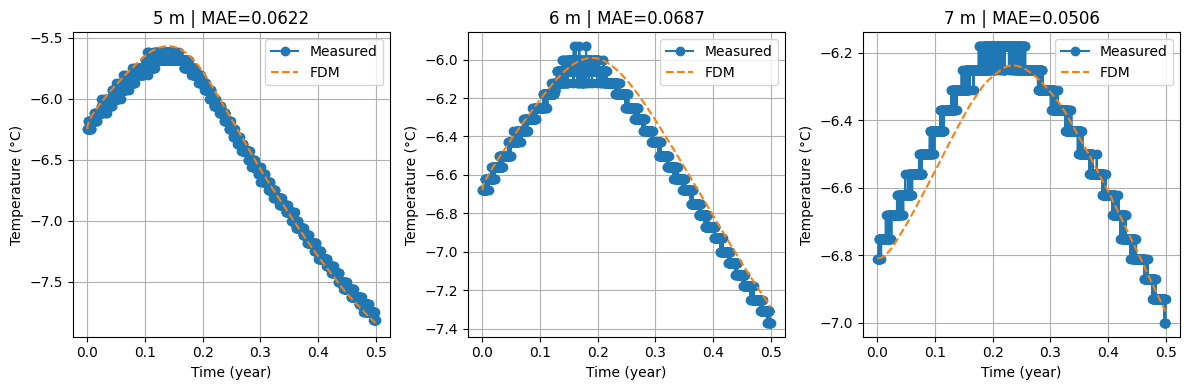


===== FDM vs field observations (5-7 m) =====
Average MAE  = 6.048852e-02
Average RMSE = 7.135269e-02
Results saved to fdm_field_4_8m_result.npz
FDM T min = -8.620000000000006
FDM T max = -4.8699999999999966
Top final T = -8.619999999999996
Bottom final T = -6.81


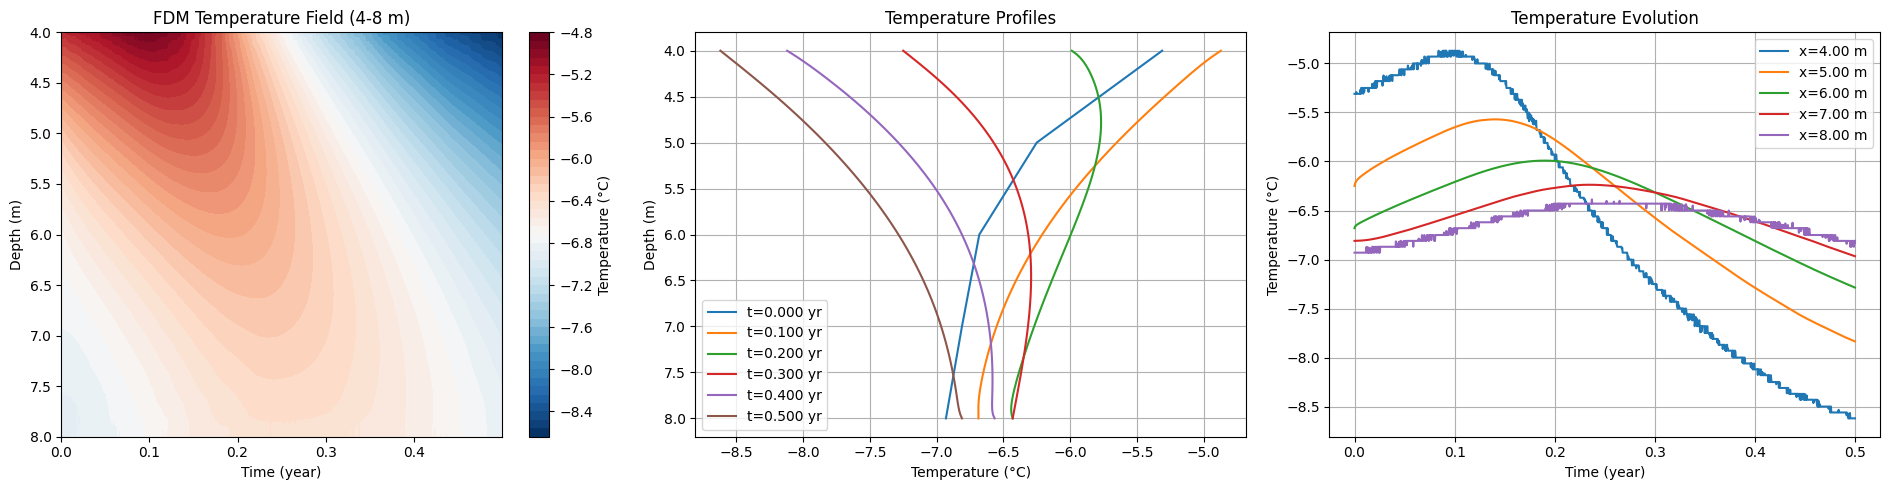

In [10]:
if __name__ == "__main__":
    params = {
        'L': 334.0,
        'C_i': 1.672,
        'C_l': 4.18,
        'C_f': 1.12, # 待估

        # keep original day-based conductivity unit
        'lambda_i': 2.210e-6 * 8.64e4,
        'lambda_l': 0.465e-6 * 8.64e4,
        'lambda_f': 1.7500e-6 * 8.64e4, # 待估

        'eta': 0.2849, # 待估 
        'theta_r': 0.10,
        'T_f': -0.3,
        'k': 0.07 # 待估
    }

    # ---------------------------
    # Load measured data
    # ---------------------------
    t_year, t_day, depth_meas, Data_sub, T_top_bc, T_bottom_bc, x_ic, T_ic = \
        load_field_data_4_8m_from_mat("DATASUB.mat")

    # ---------------------------
    # Build model
    # ---------------------------
    model = FreezingSoilFDM_LogisticAHC_Field(params)

    # measured BC and IC
    model.add_boundary_data(t_day, T_top_bc, T_bottom_bc)
    model.add_initial_condition_profile(x_ic, T_ic, kind='linear')

    # initialize domain: 4-8 m, duration based on measured data
    model.initialize(
        Nx=101,
        Nt=1500,
        x_min=4.0,
        x_max=8.0,
        T_total_days=t_day.max()
    )

    # solve
    T_field_fdm = model.solve_implicit(verbose=True)

    # compare with measured 5/6/7 m
    mae_field, rmse_field = compare_with_field_data(
        model, t_year, t_day, depth_meas, Data_sub
    )

    # save
    model.save_results("fdm_field_4_8m_result.npz")

    np.savez(
        "fdm_field_4_8m_eval.npz",
        x_fdm=model.x,
        t_fdm_day=model.t,
        t_fdm_year=model.t / 365.0,
        T_field_fdm=model.T_field,
        mae_field=mae_field,
        rmse_field=rmse_field
    )

    print("FDM T min =", np.min(T_field_fdm))
    print("FDM T max =", np.max(T_field_fdm))
    print("Top final T =", T_field_fdm[0, -1])
    print("Bottom final T =", T_field_fdm[-1, -1])

    model.plot_results()